In [ ]:
# Installs the correct modules to a users system using magic

%pip install -q pandas
%pip install -q matplotlib
%pip install -q scikit-learn


# Required Packages
import pandas as pd
import os
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

warnings.filterwarnings("ignore")

In [110]:
# PREPARE THE DATA: 
# ---------------------------------------------------------

# Gathers all json in the directory and concatenates into a dataframe
paths = ['./Data/Luna - Spotify Streaming History', './Data/Kit - Spotify Streaming History', './Data/Madison - Spotify Streaming History', './Data/Complete Streaming History']
folder_path = paths[3]

json_files = [f for f in os.listdir(folder_path) if f.endswith('.json')]

df_list = []
for file_name in json_files:
    full_path = os.path.join(folder_path, file_name)
    df_list.append(pd.read_json(full_path))

df = pd.concat(df_list, ignore_index=True)



# Convert string to datetime
df['ts'] = pd.to_datetime(df['ts'], utc=True).dt.tz_convert('America/New_York')
#Sort values and reset index
df = df.sort_values(by='ts')
df = df.reset_index()

# Track, Artist, and Timestamp ordered by timestamp
# print(df[['master_metadata_track_name', 'master_metadata_album_artist_name', 'ts']].head())
df = df.drop(['audiobook_uri', 'audiobook_title', 'spotify_track_uri', 'ip_addr', 'platform', 'conn_country', 'index', 'episode_name', 'episode_show_name', 'spotify_episode_uri', 'audiobook_chapter_uri', 'audiobook_chapter_title', 'offline_timestamp', 'incognito_mode', 'offline'], axis=1)

df

,ts,ms_played,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,reason_start,reason_end,shuffle,skipped
0,2018-05-30 15:18:37-04:00,28671,Misery Business,Paramore,Riot!,clickrow,endplay,False,False
1,2018-05-30 15:19:29-04:00,35626,Lucid Dreams,Juice WRLD,Goodbye & Good Riddance,clickrow,endplay,False,False
2,2018-05-30 15:20:29-04:00,59861,no tears left to cry,Ariana Grande,no tears left to cry,clickrow,fwdbtn,False,False
3,2018-05-30 15:20:30-04:00,789,TATI,6ix9ine,TATI,fwdbtn,backbtn,False,False
4,2018-05-30 15:21:15-04:00,27840,no tears left to cry,Ariana Grande,no tears left to cry,backbtn,endplay,False,False
...,...,...,...,...,...,...,...,...,...
707060,2026-03-15 17:58:52-04:00,234780,Your New Cuckoo,The Cardigans,First Band On The Moon,trackdone,trackdone,True,False
707061,2026-03-15 18:00:16-04:00,82782,That Girl,Esthero,Breath From Another,trackdone,fwdbtn,True,True
707062,2026-03-15 18:01:53-04:00,97088,Tomorrow,The Cardigans,Life,fwdbtn,endplay,True,True
707063,2026-03-15 18:06:16-04:00,263827,Blurred Lines,Robin Thicke,Blurred Lines,clickrow,trackdone,True,False


In [97]:
# Track Listen Counter
def track_counts(df, start_date='1000-01-01', end_date='9999-12-31', ascending=False):
    return df[(df['ts'] >= min(start_date, end_date)) & (df['ts'] < max(start_date, end_date))]['master_metadata_track_name'].value_counts().sort_values(ascending=ascending)

# Album Listen Counter
def album_counts(df, start_date='1000-01-01', end_date='9999-12-31', ascending=False):
    return df[(df['ts'] >= min(start_date, end_date)) & (df['ts'] < max(start_date, end_date))]['master_metadata_album_album_name'].value_counts().sort_values(ascending=ascending)

# Artist Listen Counter
def artist_counts(df, start_date='1000-01-01', end_date='9999-12-31', ascending=False):
    return df[(df['ts'] >= min(start_date, end_date)) & (df['ts'] < max(start_date, end_date))]['master_metadata_album_artist_name'].value_counts().sort_values(ascending=ascending)


In [98]:
# Printing results of listening counts

print('Track Listen Counts:\n', track_counts(df).head(), '\n\n\n')

print('Artist Listen Counts:\n', artist_counts(df).head(), '\n\n\n')

print('Album Listen Counts:\n', album_counts(df).head(), '\n\n\n')


Track Listen Counts:
 master_metadata_track_name
Lovefool                                   172
Love Will Tear Us Apart - 2020 Remaster    161
EARFQUAKE                                  129
Pink + White                               128
Love My Way                                127
Name: count, dtype: int64 



Artist Listen Counts:
 master_metadata_album_artist_name
Rav                   1627
Kanye West            1293
Tyler, The Creator    1161
Kendrick Lamar         860
Nirvana                846
Name: count, dtype: int64 



Album Listen Counts:
 master_metadata_album_album_name
B-Sides Vol.3 (2011-2015)          801
Sublime                            424
Beneath the Toxic Jungle           395
IGOR                               338
Man On The Moon: The End Of Day    319
Name: count, dtype: int64 





In [99]:
counts = track_counts(df)

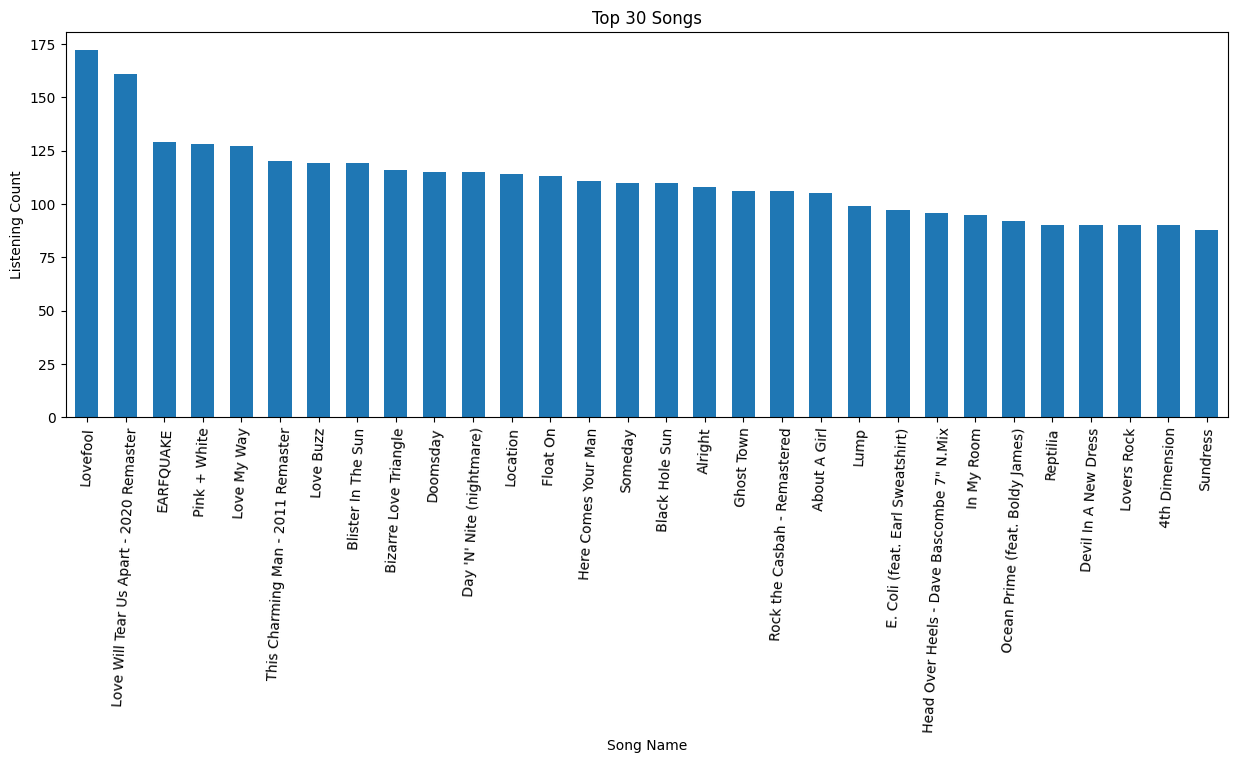

In [100]:
counts[:30].plot.bar(width=0.6, figsize=(15, 5), rot=87)
plt.title("Top 30 Songs")
plt.xlabel("Song Name")
plt.ylabel("Listening Count")
plt.show()

Text(0, 0.5, 'Listening Count')

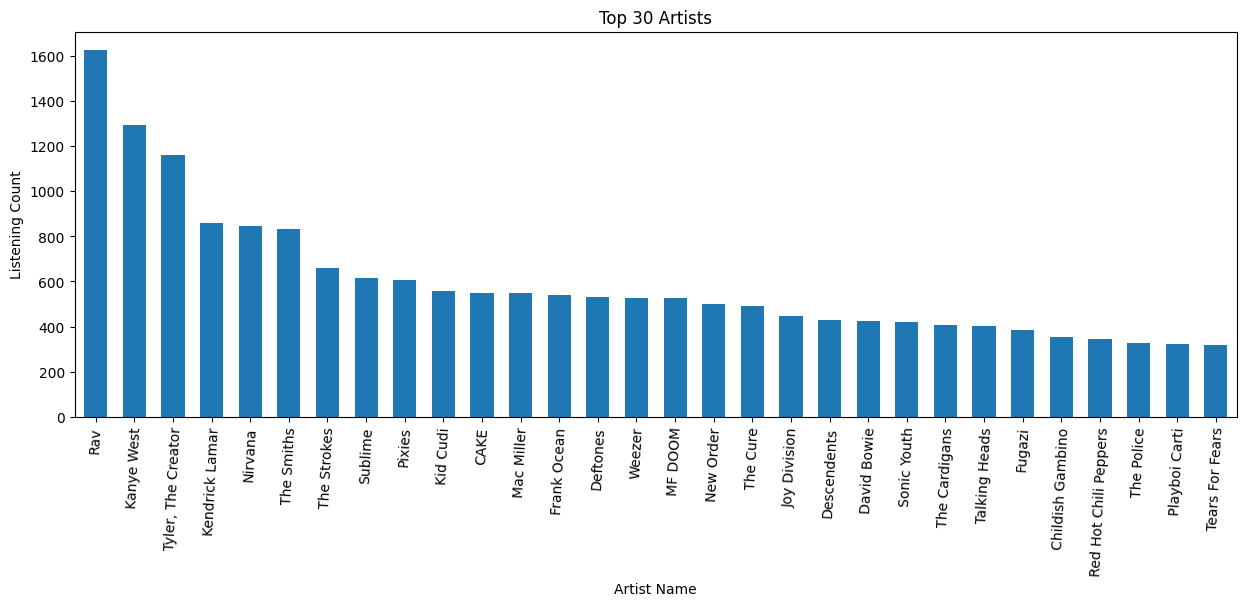

In [101]:
#meshs code:
artist_tally = artist_counts(df)
artist_tally[:30].plot.bar(width=0.6, figsize=(15, 5), rot=87)
plt.title("Top 30 Artists")
plt.xlabel("Artist Name")
plt.ylabel("Listening Count")

In [102]:
dftime = df[(df['ts'] >= '01-01-2025') & (df['ts'] < '01-02-2025')]['ts']
dftime

Series([], Name: ts, dtype: datetime64[us, America/New_York])

Text(0.5, 1.0, 'Songs Listened to by Hour of Day')

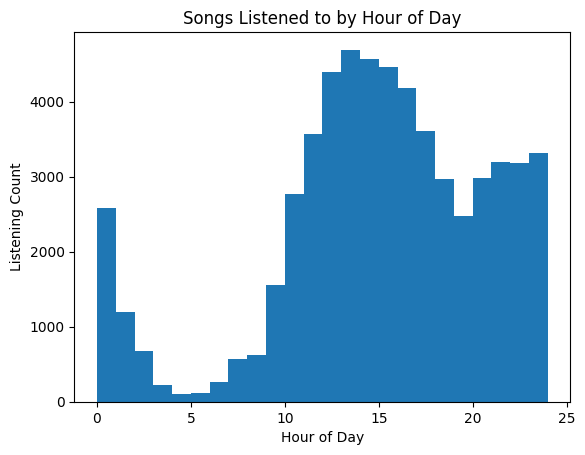

In [103]:
plt.hist(df[(df['ts'] >= '01-01-2000') & (df['ts'] < '01-01-2026')]['ts'].dt.hour, bins=24, range=(0, 24))
plt.xlabel("Hour of Day")
plt.ylabel("Listening Count")
plt.title("Songs Listened to by Hour of Day")

In [104]:
skipped = df[df['skipped']]['master_metadata_track_name'].value_counts().sort_values(ascending=False)



track_stats = pd.DataFrame({'total_listens': counts, 'skips': skipped})
track_stats['skips'] = track_stats['skips'].fillna(0)

track_stats['skip_rate'] = track_stats['skips'] / track_stats['total_listens']

track_stats_filtered = track_stats[track_stats['total_listens'] >= 50]

track_stats = track_stats_filtered.sort_values(by='skip_rate', ascending=False)

artist_map = df.drop_duplicates(subset=['master_metadata_track_name']).set_index('master_metadata_track_name')['master_metadata_album_artist_name']

track_stats['artist'] = track_stats.index.map(artist_map)

track_stats = track_stats[['artist', 'total_listens', 'skips', 'skip_rate']]

track_stats.index.name = 'track_name'

track_stats_final = track_stats.reset_index()

track_stats_final = track_stats_final[['track_name', 'artist', 'total_listens', 'skips', 'skip_rate']]

track_stats_final[:30]

,track_name,artist,total_listens,skips,skip_rate
0,Hey Ya!,Outkast,67,38.0,0.567164
1,a lot,21 Savage,51,28.0,0.549020
2,Freaking Out the Neighborhood,Mac DeMarco,55,26.0,0.472727
3,Covet,Basement,50,22.0,0.440000
4,1979 - Remastered 2012,The Smashing Pumpkins,62,27.0,0.435484
5,Let Go,Aaron May,51,22.0,0.431373
6,See You Again (feat. Kali Uchis),"Tyler, The Creator",57,24.0,0.421053
7,Deceptacon,Le Tigre,69,29.0,0.420290
8,Father Stretch My Hands Pt. 1,Kanye West,71,28.0,0.394366
9,Duvet,bôa,72,28.0,0.388889


In [108]:
# Good idea to only use with one users data, it's pretty hard to predict 3 completely different people

# Used 3 different steps to predict a users skip rate

# 1. ORGANIZE THE DATA
# ---------------------------------------------------------
# Copy over the data to a new df
ml_df = df.dropna(subset=['skipped', 'reason_start', 'master_metadata_track_name']).copy()

# Map the calculated skip rate for each song to the DataFrame
ml_df['historical_skip_rate'] = ml_df['master_metadata_track_name'].map(track_stats['skip_rate']).fillna(0)

# Convert 'reason_start' to dummy variables
ml_df = pd.get_dummies(ml_df, columns=['reason_start'], drop_first=True)

# Define our Features (X) and our Target (y)
# Set our features to reason_start and our target to historical_skip_rate
feature_cols = ['historical_skip_rate'] + [col for col in ml_df.columns if 'reason_start_' in col]
X = ml_df[feature_cols]

# 1 if Skipped, 0 if Not Skipped
y = ml_df['skipped'].astype(int) 


# 2. SPLIT DATA
# ---------------------------------------------------------
# Split the X and y data between training and testing sets. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 3. TRAINING
# ---------------------------------------------------------
# Use RandomForestClassifier to create our model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=5)

# Train the model on your data
rf_model.fit(X_train, y_train)



y_pred = rf_model.predict(X_test)

# Determine the accuracy of our predicted values
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

# Determines which feature influenced our predictions the most
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("What drives your skips?")
print(feature_importances)

Model Accuracy: 76.08%

What drives your skips?
                   Feature  Importance
6   reason_start_trackdone    0.520561
3      reason_start_fwdbtn    0.200048
2    reason_start_clickrow    0.104048
1     reason_start_backbtn    0.079870
0     historical_skip_rate    0.048790
8     reason_start_unknown    0.036064
4     reason_start_playbtn    0.008463
5      reason_start_remote    0.002014
7  reason_start_trackerror    0.000142


In [106]:
clf_0 = rf_model.estimators_[0]

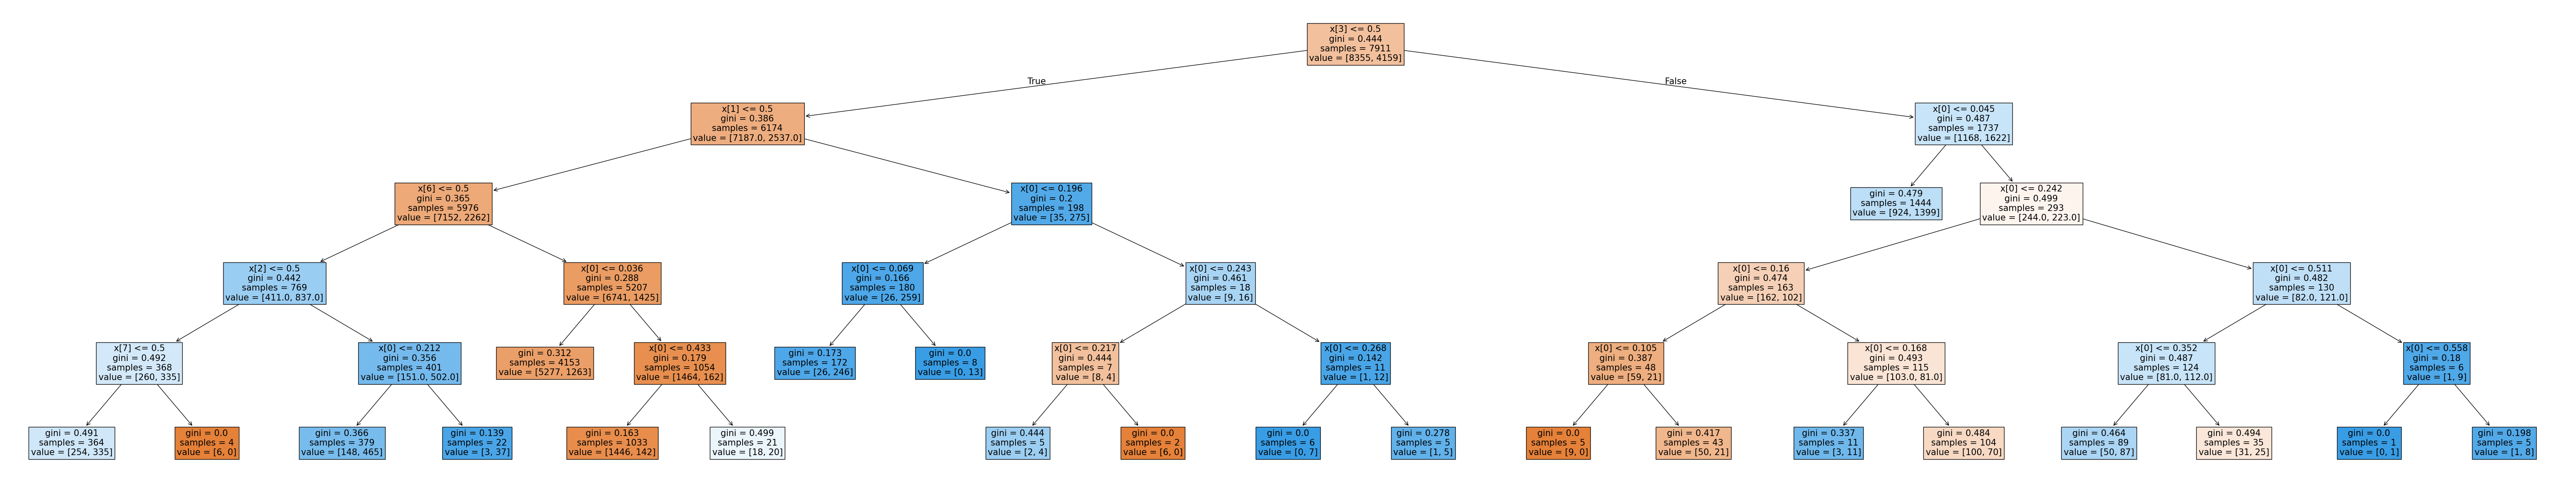

In [107]:
from sklearn import tree 

plt.figure(figsize=(80, 15)) 
tree_plot_0 = tree.plot_tree(clf_0, fontsize=15, filled=True)
plt.show()